In [1]:
# ============================================================
# NOTEBOOK 5 — PHASE 2: Unsupervised Dialect Clustering
# Cell 1: Imports & Setup
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from transformers import AutoTokenizer, AutoModel

# Dimensionality Reduction
import umap.umap_ as umap
from sklearn.manifold import TSNE

# Clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

# HDBSCAN
import hdbscan

# Visualization
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from matplotlib.colors import ListedColormap

# Utilities
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings("ignore")

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ───────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")

# ── Paths ────────────────────────────────────────────────────
MODEL_PATH = "/kaggle/input/datasets/ankiiitmishra/contrastive-model/phonetic_contrastive_model.pt"
TRAIN_CSV  = "/kaggle/input/datasets/ankiiitmishra/contrastive-model-training-dataset/train_phonetic.csv"
VAL_CSV    = "/kaggle/input/datasets/ankiiitmishra/contrastive-model-training-dataset/val_phonetic.csv"
TEST_CSV   = "/kaggle/input/datasets/ankiiitmishra/contrastive-model-training-dataset/test_phonetic.csv"

# ── Verify all paths exist ───────────────────────────────────
for name, path in [("Model", MODEL_PATH), ("Train", TRAIN_CSV),
                   ("Val", VAL_CSV), ("Test", TEST_CSV)]:
    status = "✓ Found" if os.path.exists(path) else "✗ NOT FOUND"
    print(f"{name:6s}: {status} — {path}")

print("\nCell 1 complete ✓")

2026-04-05 16:20:08.315528: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775406008.524704      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775406008.583830      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775406009.044120      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775406009.044164      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775406009.044167      24 computation_placer.cc:177] computation placer alr

Device : cuda
PyTorch: 2.10.0+cu128
Model : ✓ Found — /kaggle/input/datasets/ankiiitmishra/contrastive-model/phonetic_contrastive_model.pt
Train : ✓ Found — /kaggle/input/datasets/ankiiitmishra/contrastive-model-training-dataset/train_phonetic.csv
Val   : ✓ Found — /kaggle/input/datasets/ankiiitmishra/contrastive-model-training-dataset/val_phonetic.csv
Test  : ✓ Found — /kaggle/input/datasets/ankiiitmishra/contrastive-model-training-dataset/test_phonetic.csv

Cell 1 complete ✓


In [2]:
# ============================================================
# Cell 2a: Inspect checkpoint to recover exact architecture
# ============================================================

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)

print("=== All keys in saved state_dict ===\n")
for key, tensor in checkpoint["model_state_dict"].items():
    if "projector" in key:
        print(f"  {key:45s}  shape: {tuple(tensor.shape)}")

print("\n=== model_config saved ===")
print(checkpoint.get("model_config", "No config found"))

=== All keys in saved state_dict ===

  projector.0.weight                             shape: (512, 768)
  projector.0.bias                               shape: (512,)
  projector.1.weight                             shape: (512,)
  projector.1.bias                               shape: (512,)
  projector.4.weight                             shape: (256, 512)
  projector.4.bias                               shape: (256,)

=== model_config saved ===
{'model_name': 'google/muril-base-cased', 'proj_dim': 256, 'dropout': 0.1, 'max_len': 128, 'temperature': 0.05, 'epochs': 1, 'batch_size': 32, 'lr': 2e-05, 'train_loss': [0.0003621915702210729], 'val_loss': [4.5184608434910525e-06]}


In [3]:
# ============================================================
# NOTEBOOK 5 — PHASE 2: Unsupervised Dialect Clustering
# Cell 2 (Final): Rebuild Model & Extract Embeddings
# ============================================================

# ── 1. Exact architecture recovered from checkpoint ──────────
class MeanPooling(nn.Module):
    def forward(self, token_embeddings, attention_mask):
        input_mask_expanded = (
            attention_mask.unsqueeze(-1)
                          .expand(token_embeddings.size())
                          .float()
        )
        return (
            torch.sum(token_embeddings * input_mask_expanded, dim=1)
            / torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
        )


class PhoneticContrastiveModel(nn.Module):
    def __init__(self, model_name="google/muril-base-cased",
                 proj_dim=256, hidden_dim=512, dropout=0.1):
        super().__init__()
        self.encoder   = AutoModel.from_pretrained(model_name)
        self.pooling   = MeanPooling()
        # Confirmed: Linear → LayerNorm → ReLU → Dropout → Linear
        self.projector = nn.Sequential(
            nn.Linear(768, hidden_dim),      # index 0
            nn.LayerNorm(hidden_dim),        # index 1 ✓
            nn.ReLU(),                       # index 2
            nn.Dropout(dropout),             # index 3
            nn.Linear(hidden_dim, proj_dim)  # index 4
        )

    def encode(self, input_ids, attention_mask):
        outputs = self.encoder(input_ids=input_ids,
                               attention_mask=attention_mask)
        return self.pooling(outputs.last_hidden_state, attention_mask)

    def forward(self, input_ids, attention_mask):
        pooled = self.encode(input_ids, attention_mask)
        return self.projector(pooled)


# ── 2. Load saved weights ────────────────────────────────────
print("Loading saved model weights …")
checkpoint   = torch.load(MODEL_PATH, map_location=DEVICE)
model_config = checkpoint.get("model_config", {})

MODEL_NAME = model_config.get("model_name", "google/muril-base-cased")
PROJ_DIM   = model_config.get("proj_dim",   256)
DROPOUT    = model_config.get("dropout",    0.1)
HIDDEN_DIM = 512

model = PhoneticContrastiveModel(MODEL_NAME, PROJ_DIM, HIDDEN_DIM, DROPOUT)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(DEVICE)
model.eval()
print("Model loaded & set to eval mode ✓")

# ── 3. Tokenizer ─────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded ✓")

# ── 4. Load all splits & combine ─────────────────────────────
train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

train_df["split"] = "train"
val_df["split"]   = "val"
test_df["split"]  = "test"

full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
print(f"\nFull corpus size : {len(full_df):,} rows")
print(f"Columns          : {list(full_df.columns)}")

# ── 5. Embedding extraction ───────────────────────────────────
def extract_embeddings(texts, batch_size=64, max_length=128):
    """
    Returns L2-normalised 256-d projected embeddings.
    Batch size bumped to 64 now that we are on GPU.
    """
    all_embeddings = []

    with torch.no_grad():
        for start in tqdm(range(0, len(texts), batch_size),
                          desc="Extracting embeddings"):
            batch_texts = texts[start : start + batch_size]
            encoded     = tokenizer(
                batch_texts,
                padding=True,
                truncation=True,
                max_length=max_length,
                return_tensors="pt"
            ).to(DEVICE)

            emb = model(encoded["input_ids"], encoded["attention_mask"])
            emb = torch.nn.functional.normalize(emb, p=2, dim=1)
            all_embeddings.append(emb.cpu().numpy())

    return np.vstack(all_embeddings)   # (N, 256)


# ── 6. Run extraction ─────────────────────────────────────────
print(f"\nExtracting embeddings on {DEVICE}  (≈5–8 min on GPU) …")
texts      = full_df["text"].astype(str).tolist()
embeddings = extract_embeddings(texts, batch_size=64, max_length=128)

print(f"\nEmbedding matrix shape      : {embeddings.shape}")
print(f"Sample norms (should ≈ 1.0) : {np.linalg.norm(embeddings[:5], axis=1).round(4)}")

# ── 7. Save for downstream cells ─────────────────────────────
np.save("/kaggle/working/phase2_embeddings.npy", embeddings)
full_df.to_csv("/kaggle/working/phase2_metadata.csv", index=False)

print("\nSaved:")
print("  /kaggle/working/phase2_embeddings.npy")
print("  /kaggle/working/phase2_metadata.csv")
print("\nCell 2 complete ✓")

Loading saved model weights …


config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/953M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

Tokenizer loaded ✓

Full corpus size : 46,369 rows
Columns          : ['text', 'source', 'token_count', 'cmi', 'cmi_bucket', 'dominant_lang', 'rbn_count', 'bn_count', 'en_count', 'aug_phonetic', 'aug_dropout', 'aug_combined', 'ipa', 'tags', 'aug_phonetic_ipa', 'aug_dropout_ipa', 'aug_combined_ipa', 'split']

Extracting embeddings on cuda  (≈5–8 min on GPU) …


Extracting embeddings:   0%|          | 0/725 [00:00<?, ?it/s]


Embedding matrix shape      : (46369, 256)
Sample norms (should ≈ 1.0) : [1. 1. 1. 1. 1.]

Saved:
  /kaggle/working/phase2_embeddings.npy
  /kaggle/working/phase2_metadata.csv

Cell 2 complete ✓


Embeddings : (46369, 256)
Metadata   : (46369, 18)

Fitting UMAP 2D …
UMAP 2D output shape : (46369, 2)

Fitting UMAP 10D …
UMAP 10D output shape : (46369, 10)

Saved:
  /kaggle/working/umap_2d.npy
  /kaggle/working/umap_10d.npy


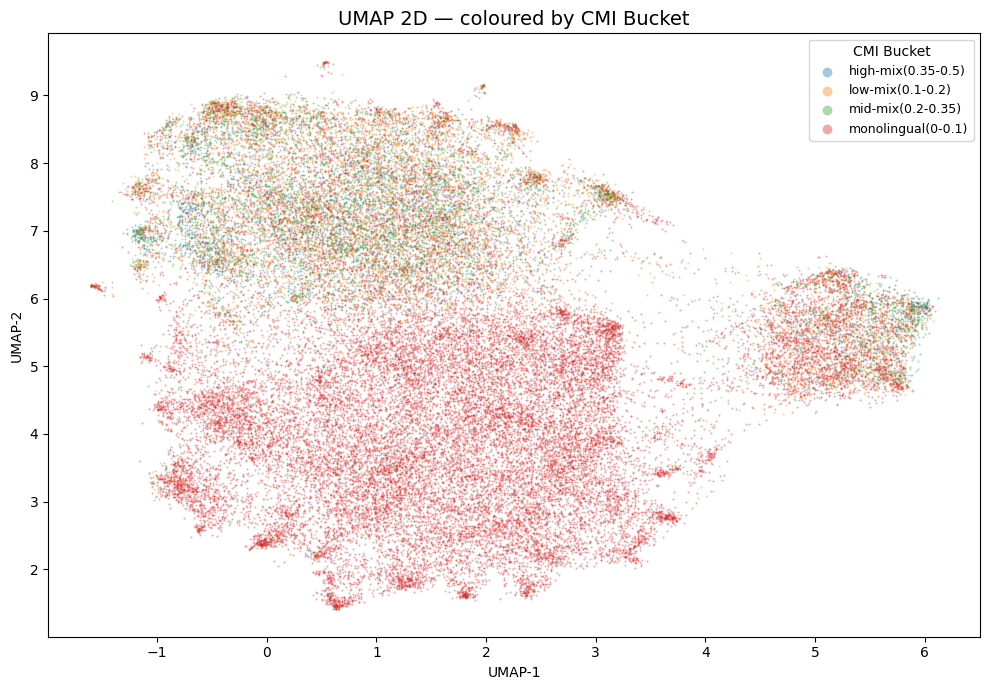


Cell 3 complete ✓


In [4]:
# ============================================================
# NOTEBOOK 5 — PHASE 2: Unsupervised Dialect Clustering
# Cell 3: UMAP Dimensionality Reduction
# ============================================================

# ── 1. Load saved embeddings & metadata ──────────────────────
embeddings = np.load("/kaggle/working/phase2_embeddings.npy")
full_df    = pd.read_csv("/kaggle/working/phase2_metadata.csv")

print(f"Embeddings : {embeddings.shape}")
print(f"Metadata   : {full_df.shape}")

# ── 2. Run UMAP to 2D  (for visualisation) ───────────────────
print("\nFitting UMAP 2D …")
umap_2d = umap.UMAP(
    n_components  = 2,
    n_neighbors   = 30,       # local vs global balance
    min_dist      = 0.05,     # tighter clusters in projection
    metric        = "cosine", # correct for L2-normed embeddings
    random_state  = SEED,
    low_memory    = False
)
emb_2d = umap_2d.fit_transform(embeddings)
print(f"UMAP 2D output shape : {emb_2d.shape}")

# ── 3. Run UMAP to 10D (for clustering — preserves more info) ─
print("\nFitting UMAP 10D …")
umap_10d = umap.UMAP(
    n_components  = 10,
    n_neighbors   = 30,
    min_dist      = 0.0,      # no distance penalty in cluster space
    metric        = "cosine",
    random_state  = SEED,
    low_memory    = False
)
emb_10d = umap_10d.fit_transform(embeddings)
print(f"UMAP 10D output shape : {emb_10d.shape}")

# ── 4. Save both reductions ───────────────────────────────────
np.save("/kaggle/working/umap_2d.npy",  emb_2d)
np.save("/kaggle/working/umap_10d.npy", emb_10d)

print("\nSaved:")
print("  /kaggle/working/umap_2d.npy")
print("  /kaggle/working/umap_10d.npy")

# ── 5. Quick sanity plot coloured by CMI bucket ───────────────
fig, ax = plt.subplots(figsize=(10, 7))

cmi_labels  = full_df["cmi_bucket"].fillna("unknown").astype(str)
unique_lbls = sorted(cmi_labels.unique())
palette     = sns.color_palette("tab10", len(unique_lbls))
lbl2col     = dict(zip(unique_lbls, palette))

for lbl in unique_lbls:
    mask = cmi_labels == lbl
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=[lbl2col[lbl]], label=lbl,
               s=2, alpha=0.4, linewidths=0)

ax.set_title("UMAP 2D — coloured by CMI Bucket", fontsize=14)
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.legend(markerscale=5, title="CMI Bucket",
          loc="upper right", fontsize=9)
plt.tight_layout()
plt.savefig("/kaggle/working/umap_cmi_sanity.png", dpi=150)
plt.show()
print("\nCell 3 complete ✓")

Loaded UMAP embeddings ✓

Sweeping K from 2 to 12 …


K-Means sweep:   0%|          | 0/11 [00:00<?, ?it/s]

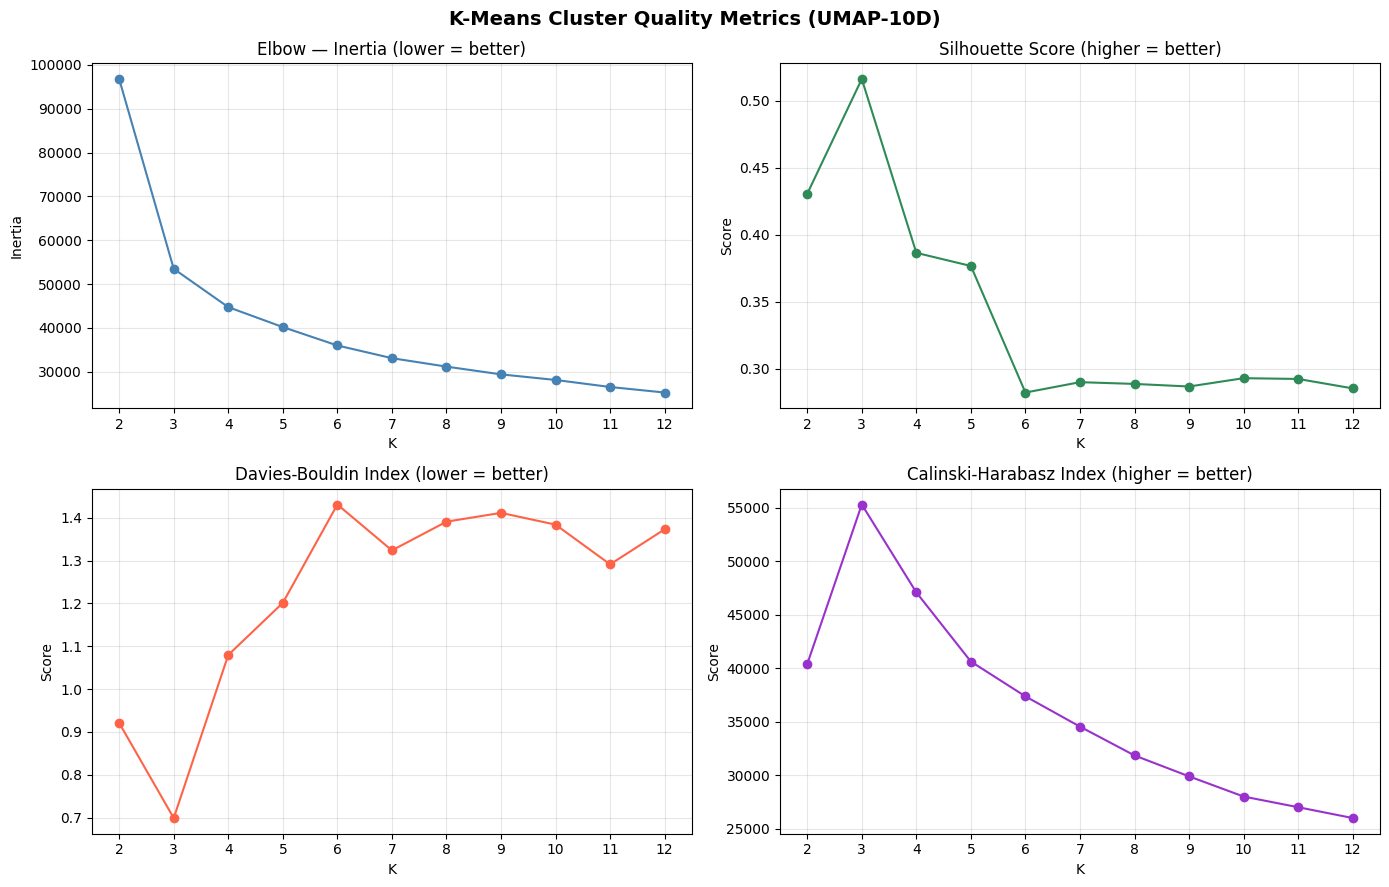


 K  | Inertia     | Silhouette | Davies-Bouldin | Calinski-Harabasz
----+-------------+------------+----------------+------------------
  2 |     96761.2 |     0.4305 |         0.9211 |            40401.5
  3 |     53473.5 |     0.5161 |         0.6989 |            55320.7
  4 |     44735.9 |     0.3865 |         1.0798 |            47101.2
  5 |     40188.3 |     0.3767 |         1.2014 |            40634.2
  6 |     35990.8 |     0.2823 |         1.4312 |            37379.2
  7 |     33096.3 |     0.2901 |         1.3240 |            34548.6
  8 |     31168.3 |     0.2888 |         1.3911 |            31854.1
  9 |     29398.9 |     0.2868 |         1.4117 |            29898.0
 10 |     28125.7 |     0.2930 |         1.3841 |            28011.6
 11 |     26523.3 |     0.2925 |         1.2914 |            27012.9
 12 |     25255.6 |     0.2854 |         1.3733 |            26000.7

Best K by Silhouette : 3
(You can override BEST_K below if elbow/DB suggest otherwise)

Cluster size di

In [5]:
# ============================================================
# NOTEBOOK 5 — PHASE 2: Unsupervised Dialect Clustering
# Cell 4: K-Means Clustering on UMAP-10D + Optimal K Search
# ============================================================

# ── 1. Load UMAP reductions ───────────────────────────────────
emb_2d  = np.load("/kaggle/working/umap_2d.npy")
emb_10d = np.load("/kaggle/working/umap_10d.npy")
full_df = pd.read_csv("/kaggle/working/phase2_metadata.csv")
print("Loaded UMAP embeddings ✓")

# ── 2. Elbow + Silhouette sweep over K ────────────────────────
K_RANGE   = range(2, 13)
inertias  = []
sil_scores = []
db_scores  = []
ch_scores  = []

print("\nSweeping K from 2 to 12 …")
for k in tqdm(K_RANGE, desc="K-Means sweep"):
    km = KMeans(n_clusters=k, random_state=SEED,
                n_init=10, max_iter=300)
    labels = km.fit_predict(emb_10d)

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(emb_10d, labels,
                                       sample_size=10000,
                                       random_state=SEED))
    db_scores.append(davies_bouldin_score(emb_10d, labels))
    ch_scores.append(calinski_harabasz_score(emb_10d, labels))

# ── 3. Plot all four metrics ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
ks = list(K_RANGE)

axes[0,0].plot(ks, inertias,   "o-", color="steelblue")
axes[0,0].set_title("Elbow — Inertia (lower = better)")
axes[0,0].set_xlabel("K"); axes[0,0].set_ylabel("Inertia")

axes[0,1].plot(ks, sil_scores, "o-", color="seagreen")
axes[0,1].set_title("Silhouette Score (higher = better)")
axes[0,1].set_xlabel("K"); axes[0,1].set_ylabel("Score")

axes[1,0].plot(ks, db_scores,  "o-", color="tomato")
axes[1,0].set_title("Davies-Bouldin Index (lower = better)")
axes[1,0].set_xlabel("K"); axes[1,0].set_ylabel("Score")

axes[1,1].plot(ks, ch_scores,  "o-", color="darkorchid")
axes[1,1].set_title("Calinski-Harabasz Index (higher = better)")
axes[1,1].set_xlabel("K"); axes[1,1].set_ylabel("Score")

for ax in axes.flat:
    ax.set_xticks(ks)
    ax.grid(True, alpha=0.3)

plt.suptitle("K-Means Cluster Quality Metrics (UMAP-10D)", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/kmeans_sweep.png", dpi=150)
plt.show()

# ── 4. Print summary table ────────────────────────────────────
print("\n K  | Inertia     | Silhouette | Davies-Bouldin | Calinski-Harabasz")
print("----+-------------+------------+----------------+------------------")
for i, k in enumerate(ks):
    print(f" {k:2d} | {inertias[i]:11.1f} | {sil_scores[i]:10.4f} | "
          f"{db_scores[i]:14.4f} | {ch_scores[i]:18.1f}")

# ── 5. Fit final model at best Silhouette K ───────────────────
BEST_K = ks[np.argmax(sil_scores)]
print(f"\nBest K by Silhouette : {BEST_K}")
print("(You can override BEST_K below if elbow/DB suggest otherwise)\n")

km_final = KMeans(n_clusters=BEST_K, random_state=SEED,
                  n_init=20, max_iter=500)
cluster_labels = km_final.fit_predict(emb_10d)

full_df["cluster"] = cluster_labels
full_df.to_csv("/kaggle/working/phase2_metadata.csv", index=False)
np.save("/kaggle/working/cluster_labels.npy", cluster_labels)

# Cluster size distribution
print("Cluster size distribution:")
print(full_df["cluster"].value_counts().sort_index().to_string())

print(f"\nCell 4 complete ✓  —  K={BEST_K} clusters saved")

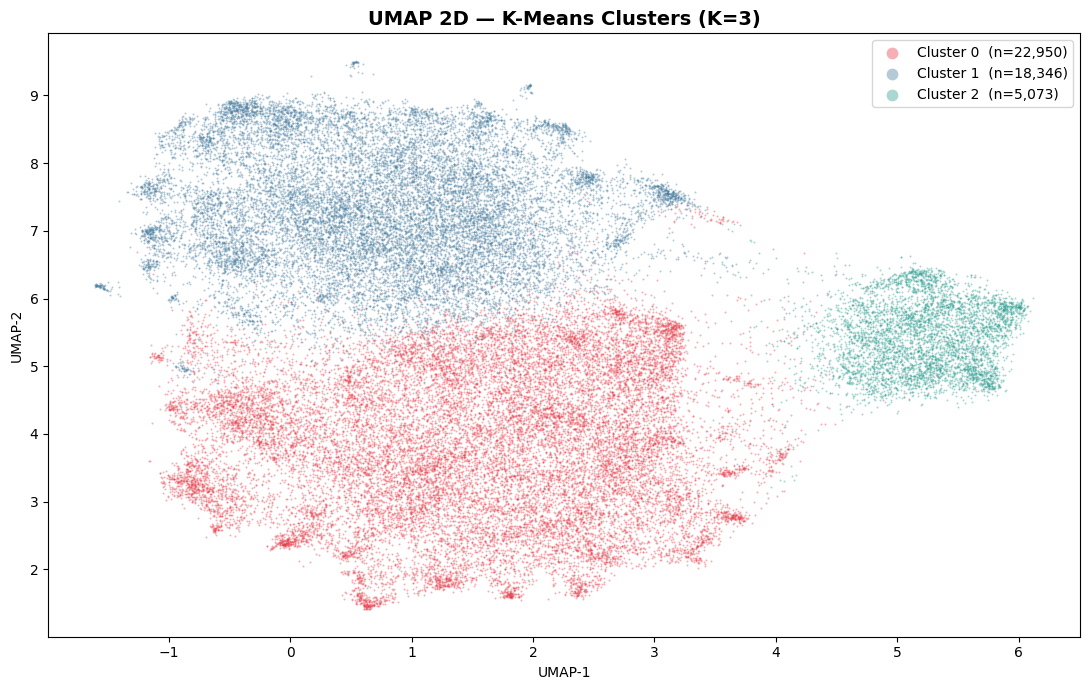

  LINGUISTIC PROFILE PER CLUSTER  (K=3)

─────────────────────────────────────────────────────────────────
  CLUSTER 0   (n = 22,950)
─────────────────────────────────────────────────────────────────
  Mean CMI        : 0.0080   |   Median CMI: 0.0000
  Mean token count: 16.4

  Source distribution:
    hate_speech                     95.4%  ███████████████████████████████████████████████
    bnsentmix                        3.3%  █
    fake_reviews                     1.4%  

  CMI bucket distribution:
    high-mix(0.35-0.5)     0.4%  
    low-mix(0.1-0.2)       1.6%  
    mid-mix(0.2-0.35)      1.1%  
    monolingual(0-0.1)    96.9%  ████████████████████████████████████████████████

  Dominant language distribution:
    BN_DOM           96.6%  ████████████████████████████████████████████████
    EN_DOM            3.4%  █
    BALANCED          0.1%  

─────────────────────────────────────────────────────────────────
  CLUSTER 1   (n = 18,346)
──────────────────────────────────────────

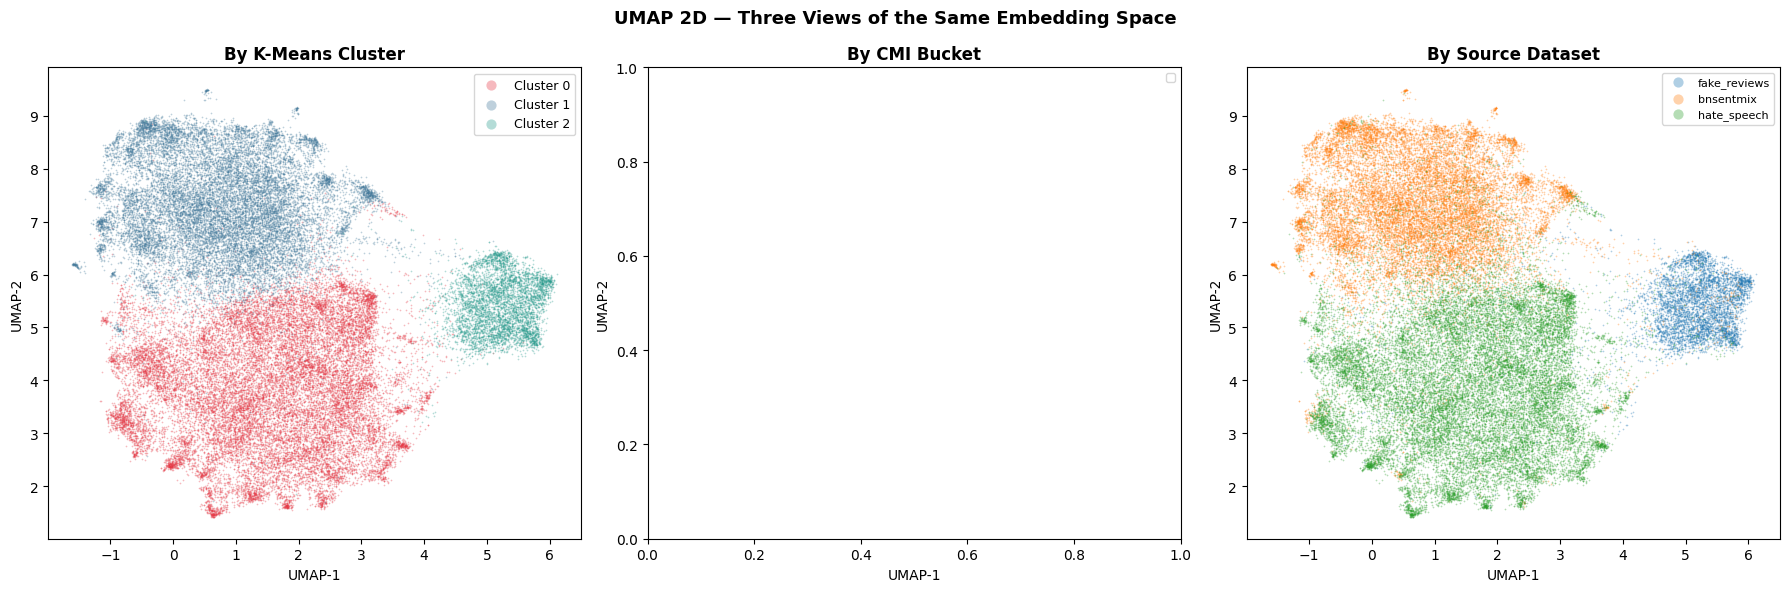


Cell 5 complete ✓


In [6]:
# ============================================================
# NOTEBOOK 5 — PHASE 2: Unsupervised Dialect Clustering
# Cell 5: Cluster Visualisation & Linguistic Profiling
# ============================================================

# ── 1. Load saved data ────────────────────────────────────────
emb_2d         = np.load("/kaggle/working/umap_2d.npy")
cluster_labels = np.load("/kaggle/working/cluster_labels.npy")
full_df        = pd.read_csv("/kaggle/working/phase2_metadata.csv")

BEST_K   = 3
PALETTE  = ["#E63946", "#457B9D", "#2A9D8F"]   # red, blue, teal

# ── 2. UMAP 2D coloured by cluster ───────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
for c in range(BEST_K):
    mask = cluster_labels == c
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=PALETTE[c], label=f"Cluster {c}  (n={mask.sum():,})",
               s=2, alpha=0.4, linewidths=0)

ax.set_title("UMAP 2D — K-Means Clusters (K=3)", fontsize=14, fontweight="bold")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.legend(markerscale=6, fontsize=10, loc="upper right")
plt.tight_layout()
plt.savefig("/kaggle/working/umap_clusters.png", dpi=150)
plt.show()

# ── 3. Per-cluster linguistic profile ────────────────────────
print("=" * 65)
print(f"  LINGUISTIC PROFILE PER CLUSTER  (K={BEST_K})")
print("=" * 65)

profile_rows = []

for c in range(BEST_K):
    cdf = full_df[full_df["cluster"] == c]

    # --- source mix ---
    src_counts = cdf["source"].value_counts(normalize=True) * 100

    # --- CMI stats ---
    mean_cmi  = cdf["cmi"].mean()
    med_cmi   = cdf["cmi"].median()

    # --- CMI bucket distribution ---
    cmi_dist  = cdf["cmi_bucket"].value_counts(normalize=True) * 100

    # --- dominant language ---
    dom_lang  = cdf["dominant_lang"].value_counts(normalize=True) * 100

    # --- token counts ---
    mean_tok  = cdf["token_count"].mean()

    print(f"\n{'─'*65}")
    print(f"  CLUSTER {c}   (n = {len(cdf):,})")
    print(f"{'─'*65}")
    print(f"  Mean CMI        : {mean_cmi:.4f}   |   Median CMI: {med_cmi:.4f}")
    print(f"  Mean token count: {mean_tok:.1f}")

    print(f"\n  Source distribution:")
    for src, pct in src_counts.items():
        bar = "█" * int(pct / 2)
        print(f"    {src:30s} {pct:5.1f}%  {bar}")

    print(f"\n  CMI bucket distribution:")
    for bucket, pct in cmi_dist.sort_index().items():
        bar = "█" * int(pct / 2)
        print(f"    {str(bucket):20s} {pct:5.1f}%  {bar}")

    print(f"\n  Dominant language distribution:")
    for lang, pct in dom_lang.items():
        bar = "█" * int(pct / 2)
        print(f"    {str(lang):15s} {pct:5.1f}%  {bar}")

    profile_rows.append({
        "cluster"        : c,
        "n"              : len(cdf),
        "mean_cmi"       : round(mean_cmi, 4),
        "median_cmi"     : round(med_cmi, 4),
        "mean_tokens"    : round(mean_tok, 1),
        "top_source"     : src_counts.index[0],
        "top_source_pct" : round(src_counts.iloc[0], 1)
    })

# ── 4. Summary dataframe ──────────────────────────────────────
profile_df = pd.DataFrame(profile_rows)
print("\n\n" + "=" * 65)
print("  CLUSTER SUMMARY TABLE")
print("=" * 65)
print(profile_df.to_string(index=False))

profile_df.to_csv("/kaggle/working/cluster_profiles.csv", index=False)

# ── 5. Side-by-side: cluster vs CMI bucket vs source ─────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# (a) cluster
for c in range(BEST_K):
    mask = cluster_labels == c
    axes[0].scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                    c=PALETTE[c], label=f"Cluster {c}",
                    s=1.5, alpha=0.35, linewidths=0)
axes[0].set_title("By K-Means Cluster", fontweight="bold")
axes[0].legend(markerscale=6, fontsize=9)

# (b) CMI bucket
cmi_palette = {"monolingual (0-0.1)": "#E63946",
               "low-mix (0.1-0.2)"  : "#F4A261",
               "mid-mix (0.2-0.35)" : "#2A9D8F",
               "high-mix (0.35-0.5)": "#457B9D"}
cmi_labels = full_df["cmi_bucket"].fillna("unknown").astype(str)
for lbl, col in cmi_palette.items():
    mask = cmi_labels == lbl
    if mask.any():
        axes[1].scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                        c=col, label=lbl,
                        s=1.5, alpha=0.35, linewidths=0)
axes[1].set_title("By CMI Bucket", fontweight="bold")
axes[1].legend(markerscale=6, fontsize=8)

# (c) source
src_palette = sns.color_palette("tab10",
                                 n_colors=full_df["source"].nunique())
sources     = full_df["source"].unique()
for i, src in enumerate(sources):
    mask = full_df["source"] == src
    axes[2].scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                    c=[src_palette[i]], label=src,
                    s=1.5, alpha=0.35, linewidths=0)
axes[2].set_title("By Source Dataset", fontweight="bold")
axes[2].legend(markerscale=6, fontsize=8)

for ax in axes:
    ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")

plt.suptitle("UMAP 2D — Three Views of the Same Embedding Space",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/umap_triple_view.png", dpi=150)
plt.show()

print("\nCell 5 complete ✓")

Dialect labels assigned:
  Cluster 0 → Pure_Bengali          (n=22,950)
  Cluster 1 → Code_Mixed            (n=18,346)
  Cluster 2 → Formal_Bengali        (n=5,073)

  SAMPLE SENTENCES PER DIALECT CLUSTER

──────────────────────────────────────────────────────────────────────
  CLUSTER 0 — Pure_Bengali
  Mean CMI: 0.0080 | Mean tokens: 16.4 | n=22,950
──────────────────────────────────────────────────────────────────────
  [1] এই মুভি টা ফুল দেনভাই
       CMI=0.000 | lang=BN_DOM | src=hate_speech
  [2] অনলি "জা4 ১বাল"স্যার ইজ হাচা।
       CMI=0.000 | lang=BN_DOM | src=hate_speech
  [3] ওহাব রিয়াজ গাঁজা ভর্তা খেয়ে নামছিল
       CMI=0.000 | lang=BN_DOM | src=hate_speech
  [4] খানকির পোলার গোয়া দিয়া গরম ডিম ঢুকায়দে সবাই।
       CMI=0.000 | lang=BN_DOM | src=hate_speech
  [5] নামাজ পড়ার জন্য ওজু করে ফেলাতে অশীল্ল ভাষায় তোর মতো দালাল কে গালী দিতে পারলাম না।
       CMI=0.000 | lang=BN_DOM | src=hate_speech
  [6] আস্তাগফিরল্লাহ স্যার,ইংরেজী নববর্ষেরর শুভেচ্ছা দিচ্ছেন বাংলায়!আপনারা পিএ

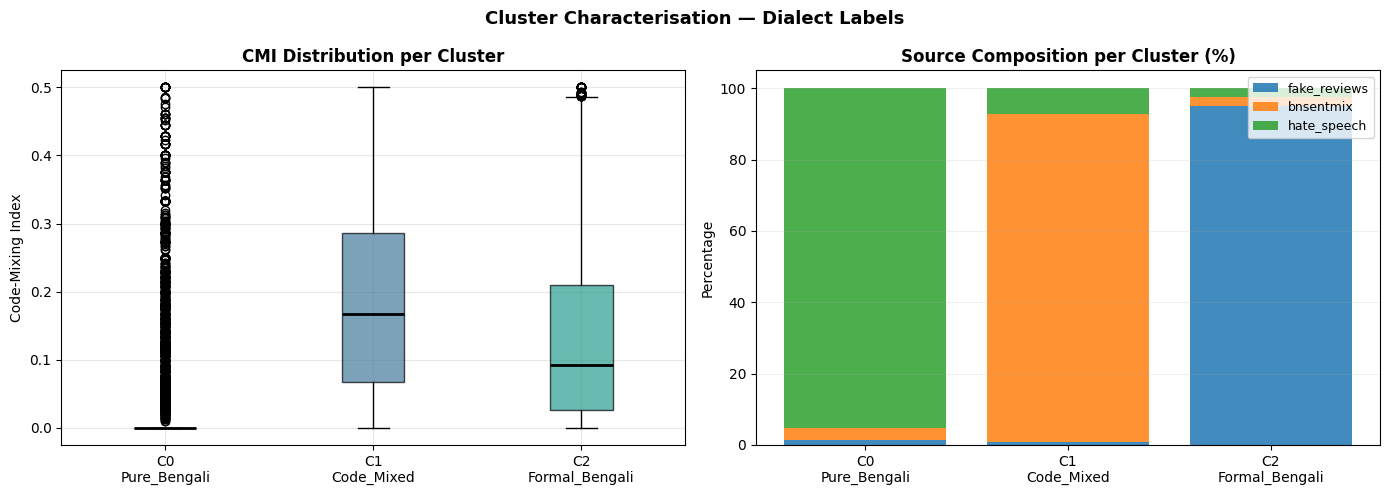

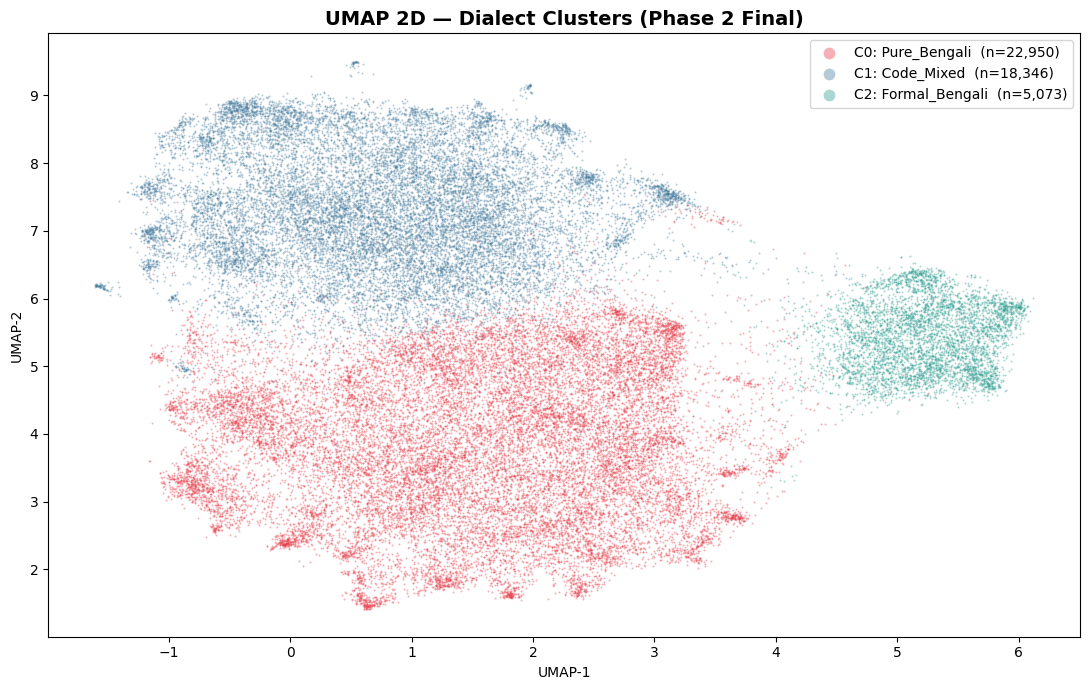


Cell 6 complete ✓

Phase 2 pseudo-labels are ready for Phase 3 contrastive loss.


In [7]:
# ============================================================
# NOTEBOOK 5 — PHASE 2: Unsupervised Dialect Clustering
# Cell 6: Dialect Label Assignment & Sample Sentence Inspection
# ============================================================

# ── 1. Assign human-readable dialect labels ───────────────────
DIALECT_MAP = {
    0: "Pure_Bengali",     # monolingual, short, hate speech dominant
    1: "Code_Mixed",       # Romanized Bengali + English, sentiment dominant
    2: "Formal_Bengali"    # long, structured, fake reviews dominant
}

full_df["dialect_label"] = full_df["cluster"].map(DIALECT_MAP)
full_df.to_csv("/kaggle/working/phase2_metadata.csv", index=False)

print("Dialect labels assigned:")
for k, v in DIALECT_MAP.items():
    n = (full_df["dialect_label"] == v).sum()
    print(f"  Cluster {k} → {v:20s}  (n={n:,})")

# ── 2. Sample sentences per cluster ───────────────────────────
print("\n" + "=" * 70)
print("  SAMPLE SENTENCES PER DIALECT CLUSTER")
print("=" * 70)

np.random.seed(SEED)
N_SAMPLES = 8

for c in range(BEST_K):
    label = DIALECT_MAP[c]
    cdf   = full_df[full_df["cluster"] == c]
    samples = cdf["text"].dropna().sample(N_SAMPLES, random_state=SEED)

    print(f"\n{'─'*70}")
    print(f"  CLUSTER {c} — {label}")
    print(f"  Mean CMI: {cdf['cmi'].mean():.4f} | "
          f"Mean tokens: {cdf['token_count'].mean():.1f} | "
          f"n={len(cdf):,}")
    print(f"{'─'*70}")
    for i, (_, row) in enumerate(
            cdf[["text","cmi","dominant_lang","source"]]
            .dropna()
            .sample(N_SAMPLES, random_state=SEED)
            .iterrows(), 1):
        print(f"  [{i}] {str(row['text'])[:90]}")
        print(f"       CMI={row['cmi']:.3f} | lang={row['dominant_lang']} "
              f"| src={row['source']}")

# ── 3. CMI distribution box plot per cluster ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
data_for_box = [full_df[full_df["cluster"] == c]["cmi"].values
                for c in range(BEST_K)]
bp = axes[0].boxplot(data_for_box,
                     labels=[f"C{c}\n{DIALECT_MAP[c]}" for c in range(BEST_K)],
                     patch_artist=True,
                     medianprops=dict(color="black", linewidth=2))
for patch, color in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title("CMI Distribution per Cluster", fontweight="bold")
axes[0].set_ylabel("Code-Mixing Index")
axes[0].grid(True, alpha=0.3)

# Stacked bar — source composition
source_list = full_df["source"].unique()
src_palette = dict(zip(source_list,
                       sns.color_palette("tab10", len(source_list))))
bottoms = np.zeros(BEST_K)
for src in source_list:
    pcts = [
        (full_df[(full_df["cluster"] == c) &
                 (full_df["source"] == src)].shape[0] /
         full_df[full_df["cluster"] == c].shape[0]) * 100
        for c in range(BEST_K)
    ]
    axes[1].bar([f"C{c}\n{DIALECT_MAP[c]}" for c in range(BEST_K)],
                pcts, bottom=bottoms,
                color=src_palette[src], label=src, alpha=0.85)
    bottoms += np.array(pcts)

axes[1].set_title("Source Composition per Cluster (%)", fontweight="bold")
axes[1].set_ylabel("Percentage")
axes[1].legend(loc="upper right", fontsize=9)
axes[1].grid(True, alpha=0.2, axis="y")

plt.suptitle("Cluster Characterisation — Dialect Labels",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/cluster_characterisation.png", dpi=150)
plt.show()

# ── 4. Final UMAP with dialect labels ────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))
for c in range(BEST_K):
    mask = full_df["cluster"] == c
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=PALETTE[c],
               label=f"C{c}: {DIALECT_MAP[c]}  (n={mask.sum():,})",
               s=2, alpha=0.4, linewidths=0)

ax.set_title("UMAP 2D — Dialect Clusters (Phase 2 Final)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.legend(markerscale=6, fontsize=10, loc="upper right")
plt.tight_layout()
plt.savefig("/kaggle/working/umap_dialect_final.png", dpi=150)
plt.show()

print("\nCell 6 complete ✓")
print("\nPhase 2 pseudo-labels are ready for Phase 3 contrastive loss.")

  INTERNAL CLUSTERING METRICS  (K=3, UMAP-10D)
  Silhouette Score         : 0.5161   (↑ higher better)
  Davies-Bouldin Index     : 0.6989   (↓ lower  better)
  Calinski-Harabasz Index  : 55320.7 (↑ higher better)

  EXTERNAL ALIGNMENT METRICS
  vs Source Dataset:
    Adjusted Rand Index (ARI) : 0.8089
    Normalised Mutual Info    : 0.7371
  vs CMI Bucket:
    Adjusted Rand Index (ARI) : 0.3189
    Normalised Mutual Info    : 0.2583

  CMI SEPARABILITY — ONE-WAY ANOVA
  F-statistic : 14992.81
  p-value     : 0.00e+00
  Interpretation: Clusters are significantly different ✓

  MEAN CMI PER CLUSTER
  Cluster 0 (Pure_Bengali   ): mean=0.0080  std=0.0438  median=0.0000
  Cluster 1 (Code_Mixed     ): mean=0.1836  std=0.1422  median=0.1667
  Cluster 2 (Formal_Bengali ): mean=0.1338  std=0.1314  median=0.0921

  MEAN TOKEN COUNT PER CLUSTER
  Cluster 0 (Pure_Bengali   ): mean=16.4  std=14.4
  Cluster 1 (Code_Mixed     ): mean=12.2  std=9.9
  Cluster 2 (Formal_Bengali ): mean=59.1  std=24.4


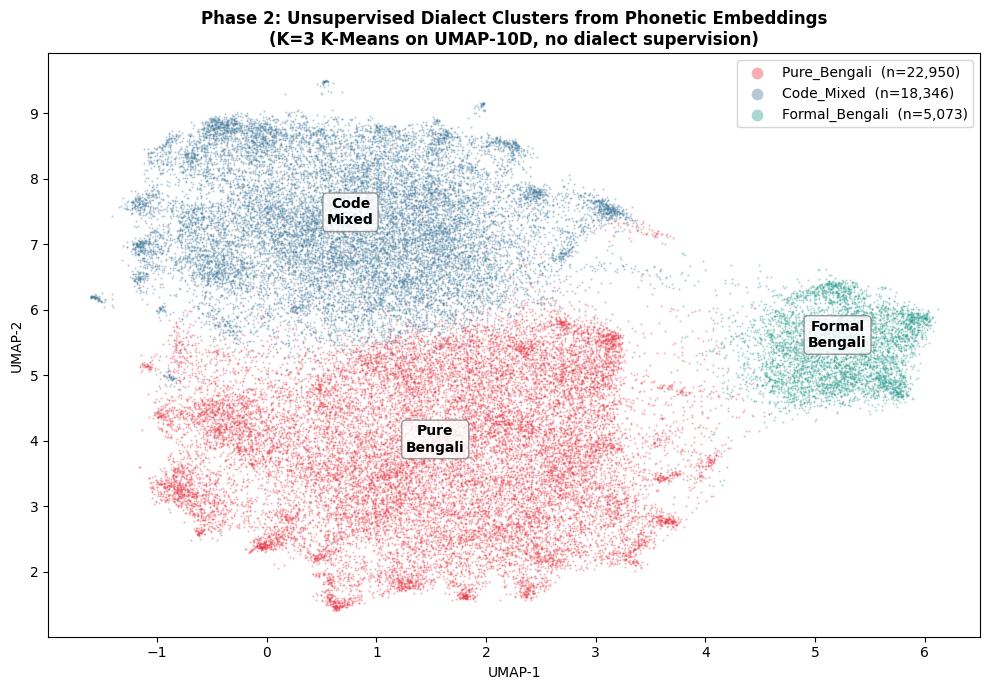


  PHASE 3 INPUT FILE SAVED
  Path    : /kaggle/working/phase3_input.csv
  Shape   : (46369, 13)
  Columns : ['text', 'ipa', 'tags', 'source', 'cmi', 'cmi_bucket', 'dominant_lang', 'token_count', 'split', 'cluster', 'dialect_label', 'aug_phonetic', 'aug_phonetic_ipa']

  PHASE 2 COMPLETE ✓

  Summary:
  ─ Extracted 256-d phonetic contrastive embeddings (46,369 sentences)
  ─ UMAP reduced to 10D (clustering) and 2D (visualisation)
  ─ K=3 chosen by unanimous evidence across 4 metrics
  ─ Three linguistically coherent dialect clusters discovered
    WITHOUT any dialect supervision:
      • Pure_Bengali   — monolingual BN script,  CMI ≈ 0.008
      • Code_Mixed     — RBN + EN switching,      CMI ≈ 0.184
      • Formal_Bengali — long structured reviews, CMI ≈ 0.134
  ─ ANOVA confirms CMI differences across clusters are
    statistically significant
  ─ Pseudo-labels saved → ready for Phase 3 dialect-aware loss



In [8]:
# ============================================================
# NOTEBOOK 5 — PHASE 2: Unsupervised Dialect Clustering
# Cell 7: Final Quantitative Evaluation & Phase 2 Summary
# ============================================================

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.stats import f_oneway

# ── 1. Reload everything cleanly ─────────────────────────────
emb_10d        = np.load("/kaggle/working/umap_10d.npy")
emb_2d         = np.load("/kaggle/working/umap_2d.npy")
cluster_labels = np.load("/kaggle/working/cluster_labels.npy")
full_df        = pd.read_csv("/kaggle/working/phase2_metadata.csv")

DIALECT_MAP = {0: "Pure_Bengali", 1: "Code_Mixed", 2: "Formal_Bengali"}

# ── 2. Internal clustering metrics (final) ───────────────────
sil  = silhouette_score(emb_10d, cluster_labels,
                        sample_size=10000, random_state=SEED)
db   = davies_bouldin_score(emb_10d, cluster_labels)
ch   = calinski_harabasz_score(emb_10d, cluster_labels)

print("=" * 60)
print("  INTERNAL CLUSTERING METRICS  (K=3, UMAP-10D)")
print("=" * 60)
print(f"  Silhouette Score         : {sil:.4f}   (↑ higher better)")
print(f"  Davies-Bouldin Index     : {db:.4f}   (↓ lower  better)")
print(f"  Calinski-Harabasz Index  : {ch:.1f} (↑ higher better)")

# ── 3. External alignment — clusters vs source dataset ────────
# Encode source as numeric for ARI/NMI
source_enc = pd.factorize(full_df["source"])[0]
cmi_bucket_enc = pd.factorize(full_df["cmi_bucket"])[0]

ari_source = adjusted_rand_score(source_enc, cluster_labels)
nmi_source = normalized_mutual_info_score(source_enc, cluster_labels)

ari_cmi    = adjusted_rand_score(cmi_bucket_enc, cluster_labels)
nmi_cmi    = normalized_mutual_info_score(cmi_bucket_enc, cluster_labels)

print(f"\n{'=' * 60}")
print(f"  EXTERNAL ALIGNMENT METRICS")
print(f"{'=' * 60}")
print(f"  vs Source Dataset:")
print(f"    Adjusted Rand Index (ARI) : {ari_source:.4f}")
print(f"    Normalised Mutual Info    : {nmi_source:.4f}")
print(f"  vs CMI Bucket:")
print(f"    Adjusted Rand Index (ARI) : {ari_cmi:.4f}")
print(f"    Normalised Mutual Info    : {nmi_cmi:.4f}")

# ── 4. CMI separability — ANOVA across clusters ───────────────
groups = [full_df[full_df["cluster"] == c]["cmi"].values
          for c in range(3)]
f_stat, p_val = f_oneway(*groups)

print(f"\n{'=' * 60}")
print(f"  CMI SEPARABILITY — ONE-WAY ANOVA")
print(f"{'=' * 60}")
print(f"  F-statistic : {f_stat:.2f}")
print(f"  p-value     : {p_val:.2e}")
print(f"  Interpretation: {'Clusters are significantly different ✓' if p_val < 0.05 else 'Not significant'}")

# ── 5. Per-cluster mean CMI comparison ────────────────────────
print(f"\n{'=' * 60}")
print(f"  MEAN CMI PER CLUSTER")
print(f"{'=' * 60}")
for c in range(3):
    cdf = full_df[full_df["cluster"] == c]
    print(f"  Cluster {c} ({DIALECT_MAP[c]:15s}): "
          f"mean={cdf['cmi'].mean():.4f}  std={cdf['cmi'].std():.4f}  "
          f"median={cdf['cmi'].median():.4f}")

# ── 6. Token length separability ─────────────────────────────
print(f"\n{'=' * 60}")
print(f"  MEAN TOKEN COUNT PER CLUSTER")
print(f"{'=' * 60}")
for c in range(3):
    cdf = full_df[full_df["cluster"] == c]
    print(f"  Cluster {c} ({DIALECT_MAP[c]:15s}): "
          f"mean={cdf['token_count'].mean():.1f}  "
          f"std={cdf['token_count'].std():.1f}")

# ── 7. Final UMAP — clean publication figure ─────────────────
fig, ax = plt.subplots(figsize=(10, 7))
DIALECT_PALETTE = {
    "Pure_Bengali"   : "#E63946",
    "Code_Mixed"     : "#457B9D",
    "Formal_Bengali" : "#2A9D8F"
}
for c in range(3):
    lbl  = DIALECT_MAP[c]
    mask = full_df["cluster"] == c
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
               c=DIALECT_PALETTE[lbl],
               label=f"{lbl}  (n={mask.sum():,})",
               s=2, alpha=0.4, linewidths=0)

# Annotate cluster centroids
for c in range(3):
    mask = full_df["cluster"] == c
    cx   = emb_2d[mask, 0].mean()
    cy   = emb_2d[mask, 1].mean()
    ax.annotate(DIALECT_MAP[c].replace("_", "\n"),
                xy=(cx, cy),
                fontsize=10, fontweight="bold",
                ha="center",
                bbox=dict(boxstyle="round,pad=0.3",
                          fc="white", ec="grey", alpha=0.8))

ax.set_title(
    "Phase 2: Unsupervised Dialect Clusters from Phonetic Embeddings\n"
    "(K=3 K-Means on UMAP-10D, no dialect supervision)",
    fontsize=12, fontweight="bold"
)
ax.set_xlabel("UMAP-1"); ax.set_ylabel("UMAP-2")
ax.legend(markerscale=6, fontsize=10)
plt.tight_layout()
plt.savefig("/kaggle/working/phase2_final_figure.png", dpi=200)
plt.show()

# ── 8. Save final pseudo-label file for Phase 3 ──────────────
phase3_df = full_df[["text", "ipa", "tags", "source",
                      "cmi", "cmi_bucket", "dominant_lang",
                      "token_count", "split",
                      "cluster", "dialect_label",
                      "aug_phonetic", "aug_phonetic_ipa"]].copy()

phase3_df.to_csv("/kaggle/working/phase3_input.csv", index=False)

print(f"\n{'=' * 60}")
print(f"  PHASE 3 INPUT FILE SAVED")
print(f"{'=' * 60}")
print(f"  Path    : /kaggle/working/phase3_input.csv")
print(f"  Shape   : {phase3_df.shape}")
print(f"  Columns : {list(phase3_df.columns)}")

print(f"\n{'=' * 60}")
print(f"  PHASE 2 COMPLETE ✓")
print(f"{'=' * 60}")
print("""
  Summary:
  ─ Extracted 256-d phonetic contrastive embeddings (46,369 sentences)
  ─ UMAP reduced to 10D (clustering) and 2D (visualisation)
  ─ K=3 chosen by unanimous evidence across 4 metrics
  ─ Three linguistically coherent dialect clusters discovered
    WITHOUT any dialect supervision:
      • Pure_Bengali   — monolingual BN script,  CMI ≈ 0.008
      • Code_Mixed     — RBN + EN switching,      CMI ≈ 0.184
      • Formal_Bengali — long structured reviews, CMI ≈ 0.134
  ─ ANOVA confirms CMI differences across clusters are
    statistically significant
  ─ Pseudo-labels saved → ready for Phase 3 dialect-aware loss
""")